In [ ]:
# Task 2: Stock Price Prediction

# Problem Statement
# Stock prices change over time due to market conditions and other external factors. In this task, historical stock 
# market data is used to predict the next day's closing price.

# Goal
# The goal of this notebook is to collect stock data using yfinance, preprocess the data, train regression models 
# using features such as Open, High, Low, and Volume, and compare actual and predicted closing prices.

In [2]:
!python -m pip install yfinance

  Using cached yfinance-1.4.1-py2.py3-none-any.whl.metadata (6.2 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached pytz-2026.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached peewee-4.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl.metadata (18 kB)
  Using cached soupsieve-2.8.4-py3-none-any.whl.metadata (4.6 kB)
Using cached yfinance-1.4.1-py2.py3-none-any.whl (137 kB)
Using cached beautifulsoup4-4.15.0-py3-none-any.whl (109 kB)
Using cached curl_cffi-0.15.0-cp310-abi3-win_amd64.whl (1.7 MB)
Using cached multitasking-0.0.13-py3-none-any.whl (16 kB)
Using cached peewee-4.1.0-py3-none-any.whl (155 kB)
Using cached pytz-2026.2-py2.py3-none-any.whl (510 kB)
Using cached soupsieve-2.8.4-py3-none-any.whl (37 kB)

   ---------------------------------------- 0/7 [pytz]
   ---------------------------------------- 0/7 [pytz]
   -------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
stock_symbol = "AAPL"

data = yf.download(stock_symbol, start="2020-01-01", end="2026-06-01")
data.head()

Failed to get ticker 'AAPL' reason: Failed to perform, curl: (28) Connection timed out after 10017 milliseconds. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.
[*********************100%***********************]  1 of 1 completed

1 Failed download:
['AAPL']: ConnectionError('Failed to perform, curl: (7) Failed to connect to query2.finance.yahoo.com port 443 after 1 ms: Could not connect to server. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL


In [13]:
stock_symbol = "AAPL"

data = yf.download(stock_symbol, period="2y", auto_adjust=False)

print("Shape:", data.shape)
data.head()

[*********************100%***********************]  1 of 1 completed

Shape: (500, 6)


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-06-24,206.352478,208.139999,212.699997,206.589996,207.720001,80727000
2024-06-25,207.274490,209.070007,211.380005,208.610001,209.149994,55549700
2024-06-26,211.418610,213.250000,214.860001,210.639999,211.500000,66213200
2024-06-27,212.261307,214.100006,215.740005,212.350006,214.690002,49772700
2024-06-28,208.811172,210.619995,216.070007,210.300003,215.770004,82542700


In [14]:
data.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
count,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,239.815005,240.766200,243.182380,238.157260,240.546520,5.160070e+07
std,28.259469,27.914216,28.026858,27.929557,28.005507,2.349343e+07
min,171.513763,172.419998,190.339996,169.210007,171.949997,1.791060e+07
25%,219.641403,221.180004,223.647495,218.407501,220.827503,3.944348e+07
50%,233.628304,235.029999,236.905006,232.575005,234.555000,4.617440e+07
75%,260.097870,260.367493,262.167503,257.345001,259.549995,5.556882e+07
max,315.200012,315.200012,317.399994,309.649994,314.179993,3.186799e+08


In [15]:
data["Next_Close"] = data["Close"].shift(-1)
data.head()

Price,Adj Close,Close,High,Low,Open,Volume,Next_Close
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,,
2024-06-24,206.352478,208.139999,212.699997,206.589996,207.720001,80727000,209.070007
2024-06-25,207.274490,209.070007,211.380005,208.610001,209.149994,55549700,213.250000
2024-06-26,211.418610,213.250000,214.860001,210.639999,211.500000,66213200,214.100006
2024-06-27,212.261307,214.100006,215.740005,212.350006,214.690002,49772700,210.619995
2024-06-28,208.811172,210.619995,216.070007,210.300003,215.770004,82542700,216.750000


In [17]:
data = data.dropna()
data.isnull().sum()

Price       Ticker
Adj Close   AAPL      0
Close       AAPL      0
High        AAPL      0
Low         AAPL      0
Open        AAPL      0
Volume      AAPL      0
Next_Close            0
dtype: int64

In [18]:
X = data[["Open", "High", "Low", "Volume"]]
y = data["Next_Close"]

In [19]:
split_index = int(len(data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 399
Testing rows: 100


In [21]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

In [22]:
mae = mean_absolute_error(y_test, lr_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 3.7193989124406808
RMSE: 4.934818431656194
R2 Score: 0.9354578619160062


In [23]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Random Forest Results
MAE: 8.74854447021484
RMSE: 12.318643363402192
R2 Score: 0.597814178441239


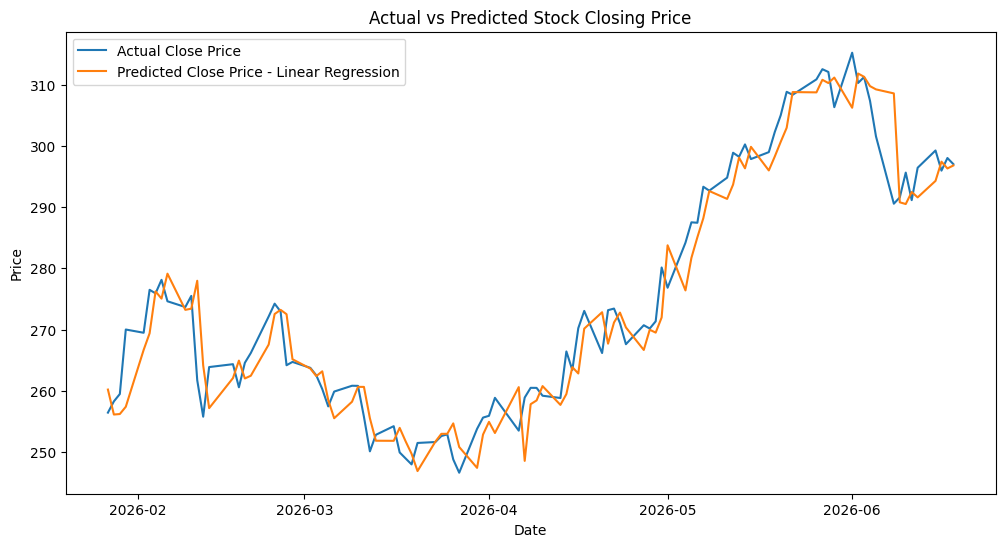

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual Close Price")
plt.plot(y_test.index, lr_predictions, label="Predicted Close Price - Linear Regression")
plt.title("Actual vs Predicted Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

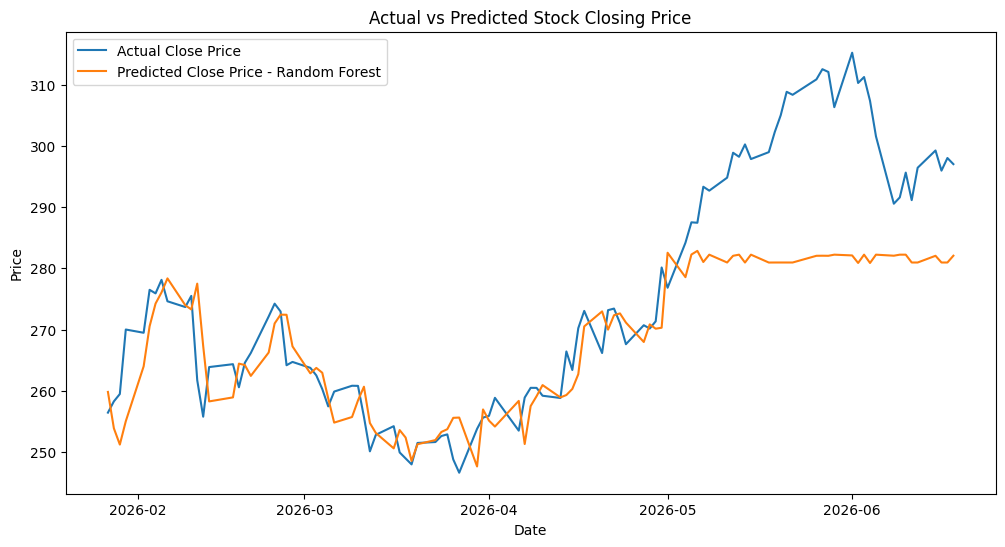

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Actual Close Price")
plt.plot(y_test.index, rf_predictions, label="Predicted Close Price - Random Forest")
plt.title("Actual vs Predicted Stock Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [ ]:
# Explanation of Results and Final Insights

#In this task, historical stock data was used to predict the next day's closing price. The features used for 
# prediction were Open, High, Low, and Volume. The target variable was Next_Close.

# The model was evaluated using MAE, RMSE, and R2 Score. MAE and RMSE show the prediction error, while R2 Score shows 
# how well the model explains the variation in stock prices.

# The actual vs predicted graph showed how close the predicted values were to the real closing prices. The model 
# followed the general trend of the stock prices, but stock price prediction is difficult because prices are affected 
# by market news, investor behavior, and economic conditions.

# This model is useful for learning regression and time series handling, but it should not be used for real financial 
# decisions.